# Poster figure inventory

**`notebooks/presentation/14_poster_figure_inventory.ipynb`**

A single, presentation-grade notebook that **collects, renders, standardises and
exports** every figure candidate for the research poster. It is a *figure
inventory*, not a pipeline: it loads existing canonical artifacts and calls
`channel_heads.*` plotting utilities — it never retrains a model or re-runs the
Mars pipeline. (It does rebuild **one** small Earth basin network with
TopoToolbox, purely to draw the Earth maps.)

* All reusable plotting lives in the package
  (`channel_heads.viz.poster` / `.earth` / `.curves`, `channel_heads.pipelines.earth`);
  the notebook only *composes* it.
* Figures are exported as **both `.svg` and `.png`** to
  `data/results/poster_figures/`.
* Every figure is wrapped so a **missing artifact prints a clear message and the
  notebook continues** with the remaining figures.
* A figure **manifest** (`poster_figure_manifest.csv` / `.md`) is written at the
  end.

**Selected regime: `regC`.** Where a regime choice exists (Earth model validation,
Mars prediction summary, Mars prediction maps and the synthesis figure) the
notebook uses the **regC** dataset/model and labels it explicitly. The
model-disagreement contact sheet is the one figure kept on the *baseline combined*
inference (geom+cnn_emb vs geom+cnn_logit), since disagreement is only defined
there.

Poster sections: **Introduction · Methods · Results · Discussion**.

## 0 · Setup and figure manifest

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import Point

from channel_heads.io import paths
from channel_heads.regimes import REGIMES
from channel_heads.rasterization.schema import OTHER_STREAMS
from channel_heads.viz import poster
from channel_heads.viz import (
    apply_poster_style, save_figure,
    pipeline_flowchart, pair_definition_concept,
    plot_5class_patch, patch_legend_handles,
    feature_distribution_panel, feature_schematic_panel, model_comparison_bars,
    mars_regime_summary_panel, select_representative_networks,
    plot_earth_outlet_map, plot_earth_pair_map,
    plot_network_overview, plot_network_on_hillshade, mars_marker_legend_handles,
    main_synthesis_figure, drainage_density_regime_panel,
    render_contact_sheet, render_outlet_touching_pairs,
    roc_curve_panel, pr_curve_panel,
)
from channel_heads.eval import holdout_split_predict

# Selected regime for every regime-dependent figure.
SELECTED_REGIME = "regC"
# "High confidence" must sit clearly ABOVE the decision threshold. The regC
# operating threshold is ~0.81, so 0.90 gives a meaningful high-confidence subset
# of the predicted-touching pairs (a 0.80 bar would fall below the threshold).
HIGH_CONF_PROB = 0.90

# --- Robust repo-root resolution (no sys.path hacks) -----------------------
ROOT = paths.PROJECT_ROOT
print("channel_heads PROJECT_ROOT :", ROOT)
print("notebook working directory :", Path.cwd())
assert (ROOT / "pyproject.toml").exists(), "PROJECT_ROOT lost its pyproject marker"

POSTER_DIR = paths.RESULTS_DIR / "poster_figures"
POSTER_DIR.mkdir(parents=True, exist_ok=True)
MARS_MAPS_DIR = POSTER_DIR / "mars_prediction_maps"
MARS_MAPS_DIR.mkdir(parents=True, exist_ok=True)
print("Figures ->", POSTER_DIR, "| selected regime:", SELECTED_REGIME)

apply_poster_style()

channel_heads PROJECT_ROOT : /Users/guypi/Projects/channel-heads
notebook working directory : /Users/guypi/Projects/channel-heads/notebooks/presentation
Figures -> /Users/guypi/Projects/channel-heads/data/results/poster_figures | selected regime: regC


In [2]:
# --- Figure manifest infrastructure ----------------------------------------
MANIFEST: list[dict] = []

def missing_inputs(sources) -> list[str]:
    return [str(s) for s in sources if s is not None and not Path(s).exists()]

def record(figure_id, title, purpose, section, sources,
           outputs=(), status="generated", missing=()):
    MANIFEST.append({
        "figure_id": figure_id,
        "title": title,
        "purpose": purpose,
        "poster_section": section,
        "source_artifacts": "; ".join(str(s) for s in sources if s is not None)
                            or "(synthetic / none)",
        "output_path": "; ".join(sorted({str(o) for o in outputs})),
        "status": status,
        "missing_inputs": "; ".join(str(m) for m in missing),
    })

def export(fig, figure_id):
    """Save both .svg and .png; keep the figure open so it renders inline."""
    return list(save_figure(fig, POSTER_DIR, figure_id,
                            formats=("svg", "png"), close=False).values())

def resolve(rel):
    if rel is None or (isinstance(rel, float) and pd.isna(rel)):
        return None
    p = Path(rel)
    return p if p.is_absolute() else (ROOT / p)

print("Manifest ready.")

Manifest ready.


In [3]:
# --- Load shared Mars prediction artifacts ---------------------------------
# Primary: the selected-regime (regC) single-model predictions.
# Secondary: the baseline *combined* predictions (emb vs logit) — only used for
# the model-disagreement figure, where disagreement is defined.
def safe_read_csv(p, **kw):
    p = Path(p)
    if not p.exists():
        print("[missing artifact]", p); return None
    return pd.read_csv(p, **kw)

def safe_read_parquet(p):
    p = Path(p)
    if not p.exists():
        print("[missing artifact]", p); return None
    return pd.read_parquet(p)

PRED = safe_read_csv(
    paths.MARS_MODEL_OUTPUTS_DIR / f"mars_combined_{SELECTED_REGIME}_predictions.csv"
)
PRED_BASE = safe_read_parquet(
    paths.MARS_MODEL_OUTPUTS_DIR / "mars_combined_model_predictions.parquet"
)

mars_nodes = mars_segs = mars_outlets = pair_paths = None
if paths.MARS_TOPOLOGY_GPKG.exists():
    mars_nodes = gpd.read_file(paths.MARS_TOPOLOGY_GPKG, layer="mars_nodes")
    mars_segs = gpd.read_file(paths.MARS_TOPOLOGY_GPKG, layer="mars_segments")
    mars_outlets = gpd.read_file(paths.MARS_TOPOLOGY_GPKG, layer="mars_outlets")
else:
    print("[missing artifact]", paths.MARS_TOPOLOGY_GPKG)

if paths.MARS_PAIRS_GPKG.exists():
    pair_paths = gpd.read_file(paths.MARS_PAIRS_GPKG, layer="mars_pair_paths")
else:
    print("[missing artifact]", paths.MARS_PAIRS_GPKG)

nodes_by_nid = dict(tuple(mars_nodes.groupby("network_id"))) if mars_nodes is not None else {}
segs_by_nid = dict(tuple(mars_segs.groupby("network_id"))) if mars_segs is not None else {}
outlets_by_nid, outlet_pt_by_nid = {}, {}
if mars_outlets is not None:
    for _, r in mars_outlets.iterrows():
        outlets_by_nid[int(r["network_id"])] = (float(r.geometry.x), float(r.geometry.y))
        outlet_pt_by_nid[int(r["network_id"])] = r.geometry
paths_lookup = {}
if pair_paths is not None:
    for _, r in pair_paths.iterrows():
        paths_lookup[(str(r["pair_id"]), str(r["branch"]))] = r.geometry

print("regC predictions:", None if PRED is None else PRED.shape,
      "| baseline:", None if PRED_BASE is None else PRED_BASE.shape,
      "| networks with geometry:", len(segs_by_nid))

regC predictions: (3682, 36) | baseline: (3785, 52) | networks with geometry: 391


In [4]:
# --- Earth networks for the Earth maps (regC, via TopoToolbox) --------------
# Sakhalin (large, complex) is used for the Fig-2 overview map. The Fig-3 pair
# examples are specific hand-picked pairs from other basins (see PAIR_EXAMPLES).
# Guarded so the Earth figures degrade gracefully if TopoToolbox is unavailable.
EARTH = None
EARTH_BASIN = "sakhalin"   # large, complex basin for the overview map (Fig 2)
EARTH_OVERVIEW_OUTLET = None
try:
    from channel_heads.pipelines import build_earth_basin_network
    from channel_heads.stream_utils import outlet_node_ids_from_streampoi

    EARTH = build_earth_basin_network(EARTH_BASIN, regime=SELECTED_REGIME)
    # Pick the largest / most complex outlet for the overview map.
    om = EARTH.s.streampoi("outlets")
    ranked = []
    for oid in outlet_node_ids_from_streampoi(EARTH.s):
        m = np.zeros_like(om, bool)
        m[oid] = True
        ranked.append(
            (int(np.asarray(EARTH.s.upstreamto(m).node_indices[0]).size), int(oid)))
    ranked.sort(reverse=True)
    if ranked:
        EARTH_OVERVIEW_OUTLET = ranked[0][1]
    print(f"Earth network built: {EARTH_BASIN} (regC) | overview outlet "
          f"{EARTH_OVERVIEW_OUTLET} ({ranked[0][0] if ranked else 0} nodes)")
except Exception as e:
    print("[earth build skipped]", repr(e))

# Fig-3 pair examples, hand-picked from the candidate gallery
# (data/results/poster_figures/pair_candidates/): T6 touching, N9 non-touching.
PAIR_EXAMPLES = {
    "touching":     dict(basin="tsugaru", confluence=682,  head_1=1094, head_2=1139),
    "non_touching": dict(basin="troodos", confluence=8053, head_1=7888, head_2=7913),
}

Earth network built: sakhalin (regC) | overview outlet 5528 (1013 nodes)


## 1 · Pipeline flowchart

The end-to-end method as a colour-coded banner, now including the **Earth↔Mars
drainage-density calibration** step (choice of stream-extraction threshold and
pruning strategy) that makes the Earth training networks comparable to the
Martian ones. Synthetic — no artifacts required.

ok 01_pipeline_flowchart


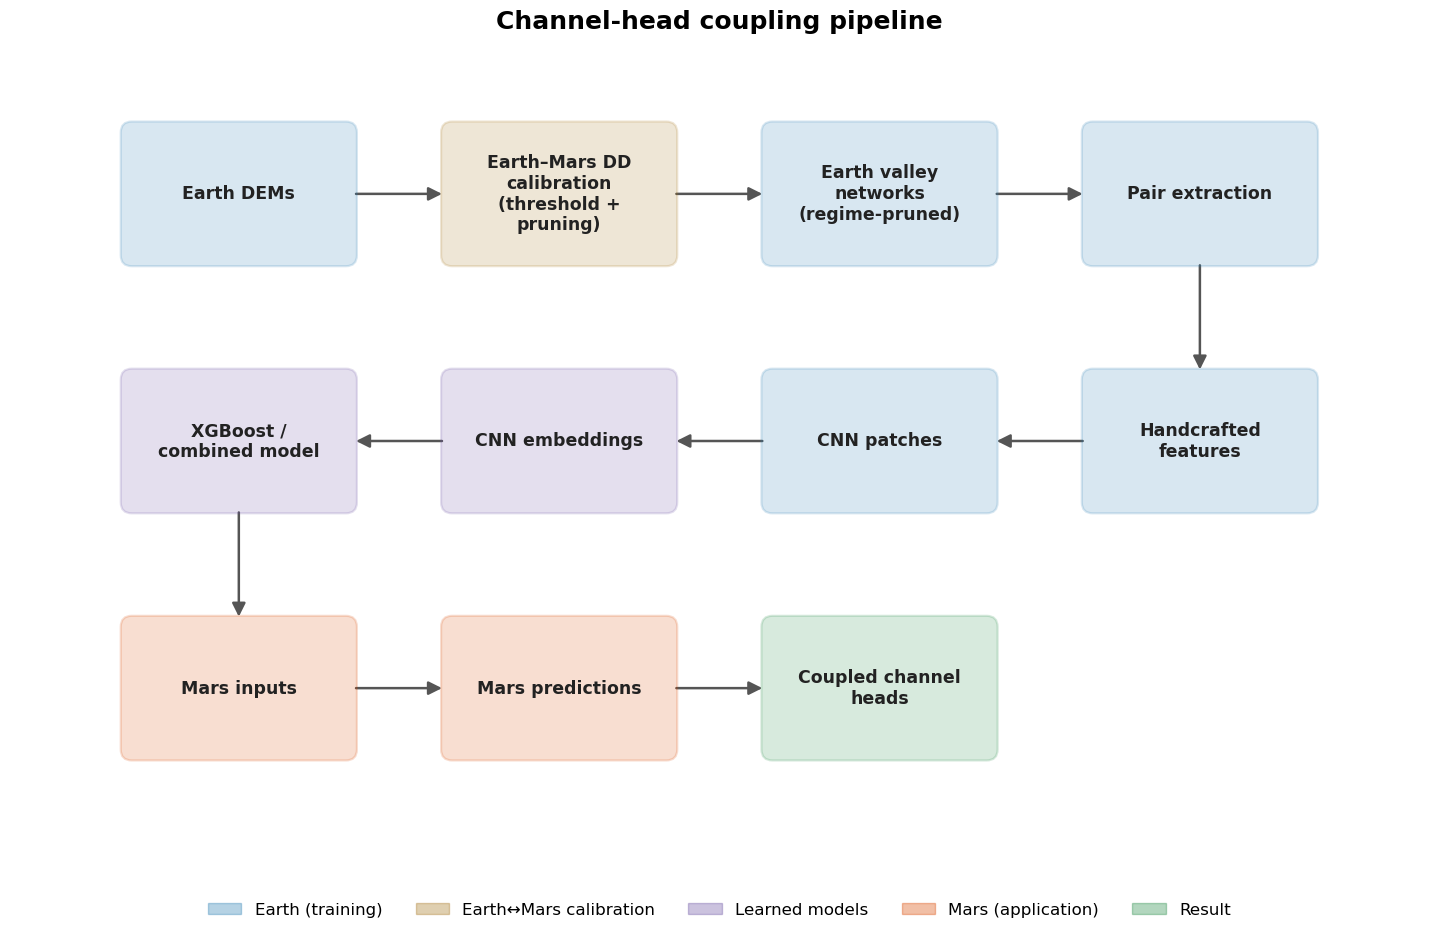

In [5]:
fid = "01_pipeline_flowchart"
sources = []
try:
    fig = pipeline_flowchart(max_per_row=4, box_w=2.5, box_h=1.5,
                             figsize=(17.5, 9.5))
    outs = export(fig, fid)
    record(fid, "Pipeline flowchart",
           "End-to-end method incl. Earth-Mars DD calibration (threshold + "
           "pruning): DEMs -> calibration -> networks -> pairs -> features/CNN "
           "-> models -> Mars inputs -> predictions -> coupled heads.",
           "Methods", sources, outs, "generated")
    print("ok", fid)
except Exception as e:
    record(fid, "Pipeline flowchart", "End-to-end method flowchart.",
           "Methods", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 2 · Earth vs Mars overview maps

Left: a large, complex **Earth** outlet rendered TopoToolbox-style — a terrain
**coloured hillshade** with the extracted valley network (blue) and channel
heads/confluences/outlet. Right: a representative **Mars** valley network
**overlaid on the MOLA hillshade** for regional context. **Both maps carry
latitude/longitude axes in degrees.**

ok 02_earth_mars_overview_maps | Mars network: 14


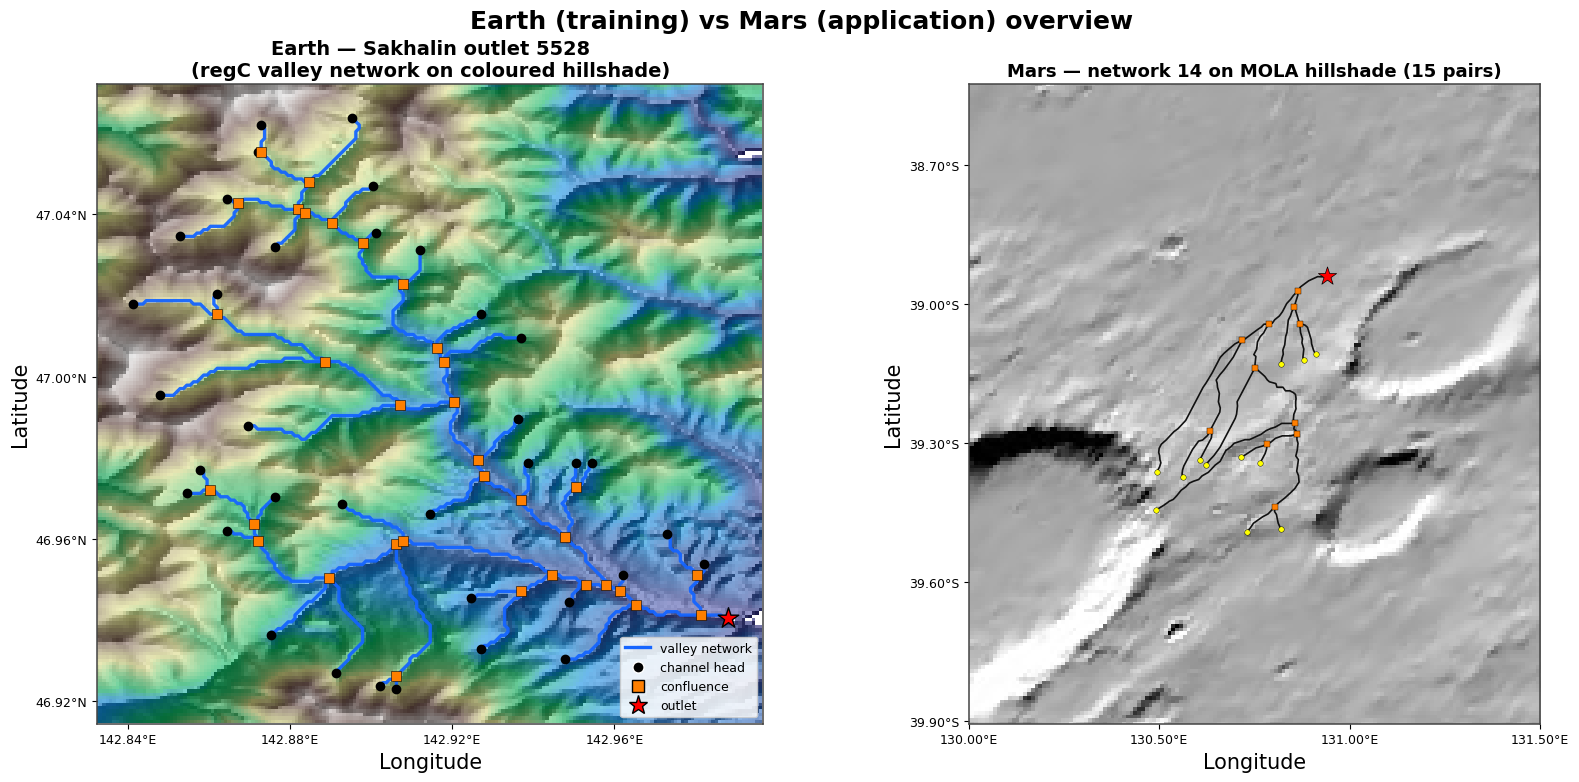

In [6]:
fid = "02_earth_mars_overview_maps"
sources = []
try:
    fig, axes = plt.subplots(1, 2, figsize=(17, 8))

    # Left — Earth coloured hillshade + network for one (large) outlet, lon/lat axes.
    if EARTH is not None and EARTH_OVERVIEW_OUTLET is not None:
        sources.append(paths.EXAMPLE_DEMS.get(EARTH_BASIN))
        plot_earth_outlet_map(axes[0], EARTH.s, EARTH.dem, EARTH_OVERVIEW_OUTLET,
                              geographic_axes=True)
        axes[0].set_title(
            f"Earth — {EARTH_BASIN.title()} outlet {EARTH_OVERVIEW_OUTLET}\n"
            f"(regC valley network on coloured hillshade)", fontsize=14)
    else:
        axes[0].text(0.5, 0.5, "Earth network unavailable\n(TopoToolbox build failed)",
                     ha="center", va="center"); axes[0].set_axis_off()

    # Right — Mars vector network on MOLA hillshade, lon/lat axes.
    nid = None
    if PRED is not None and segs_by_nid:
        cnt = PRED.groupby("network_id").size()
        cnt = cnt[cnt.index.isin(segs_by_nid)]
        cc = cnt[(cnt >= 15) & (cnt <= 40)]
        cc = cc if not cc.empty else cnt
        nid = int((cc - cnt.median()).abs().idxmin())
        sources += [paths.MARS_TOPOLOGY_GPKG, paths.MARS_HILLSHADE]
        ext = plot_network_on_hillshade(
            axes[1], segs_by_nid[nid], paths.MARS_HILLSHADE,
            nodes_n=nodes_by_nid.get(nid), outlet_geom=outlet_pt_by_nid.get(nid),
            geographic_axes=True,
            title=f"Mars — network {nid} on MOLA hillshade ({int(cnt[nid])} pairs)")
        if ext is None:  # MOLA unavailable -> clean vector fallback
            axes[1].clear()
            plot_network_overview(axes[1], segs_by_nid[nid], nodes_by_nid.get(nid),
                                  outlets_by_nid.get(nid),
                                  title=f"Mars network {nid} ({int(cnt[nid])} pairs)")
            axes[1].legend(handles=mars_marker_legend_handles(), loc="lower right",
                           fontsize=9, frameon=True)
    else:
        axes[1].text(0.5, 0.5, "Mars topology unavailable", ha="center", va="center")
        axes[1].set_axis_off()

    fig.suptitle("Earth (training) vs Mars (application) overview",
                 fontsize=18, fontweight="bold")
    fig.tight_layout()
    outs = export(fig, fid)
    record(fid, "Earth vs Mars overview maps",
           "Earth outlet (coloured hillshade + network) beside a Mars network "
           "overlaid on MOLA.",
           "Introduction", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid, "| Mars network:", nid)
except Exception as e:
    record(fid, "Earth vs Mars overview maps", "Earth/Mars side-by-side overview.",
           "Introduction", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 3 · Pair definition concept

Hand-picked real **Earth** examples (regC) of the coupling concept: a **touching**
pair from Tsugaru (the two channel heads' contributing areas are adjacent) versus
a **non-touching** pair from Troodos (heads close, plausibly a pair, but their
contributing areas do not touch). The two upstream contributing areas are drawn as
**distinct solid (opaque)** patches so they read clearly, with the valley network
in **blue** on top, and **lat/lon degree axes**. Falls back to a synthetic
schematic if the Earth network is unavailable.

ok 03_pair_definition_concept


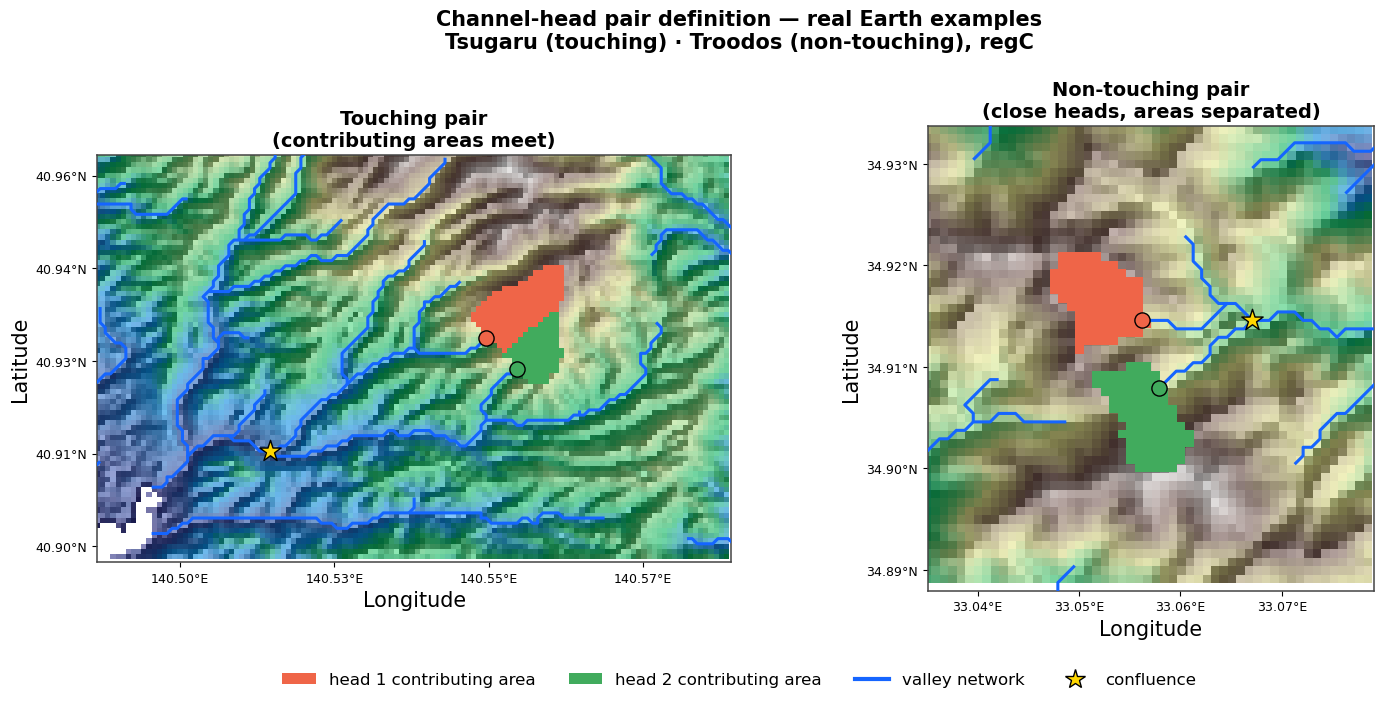

In [7]:
fid = "03_pair_definition_concept"
sources = []
try:
    from channel_heads.pipelines import build_earth_basin_network
    from channel_heads.viz.earth import (
        PAIR_AREA_COLOR_1, PAIR_AREA_COLOR_2, PAIR_STREAM_COLOR,
    )
    tcfg, ncfg = PAIR_EXAMPLES["touching"], PAIR_EXAMPLES["non_touching"]
    pair_nets = {}
    for cfg in (tcfg, ncfg):
        b = cfg["basin"]
        if b not in pair_nets:
            pair_nets[b] = build_earth_basin_network(b, regime=SELECTED_REGIME)
            sources.append(paths.EXAMPLE_DEMS.get(b))

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    nt = pair_nets[tcfg["basin"]]
    plot_earth_pair_map(axes[0], nt.fd, nt.s, nt.dem,
                        tcfg["confluence"], tcfg["head_1"], tcfg["head_2"],
                        geographic_axes=True,
                        title="Touching pair\n(contributing areas meet)")
    nn = pair_nets[ncfg["basin"]]
    plot_earth_pair_map(axes[1], nn.fd, nn.s, nn.dem,
                        ncfg["confluence"], ncfg["head_1"], ncfg["head_2"],
                        geographic_axes=True,
                        title="Non-touching pair\n(close heads, areas separated)")
    handles = [
        Patch(facecolor=PAIR_AREA_COLOR_1, label="head 1 contributing area"),
        Patch(facecolor=PAIR_AREA_COLOR_2, label="head 2 contributing area"),
        Line2D([0], [0], color=PAIR_STREAM_COLOR, lw=3, label="valley network"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="gold",
               markeredgecolor="k", markersize=15, linestyle="", label="confluence"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
               bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(
        "Channel-head pair definition — real Earth examples\n"
        f"{tcfg['basin'].title()} (touching) · {ncfg['basin'].title()} "
        f"(non-touching), regC", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    outs = export(fig, fid)
    record(fid, "Pair definition concept",
           f"Real Earth touching pair ({tcfg['basin']}) and non-touching pair "
           f"({ncfg['basin']}): contributing-area contact vs separation.",
           "Methods", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid)
except Exception as e:
    # Synthetic fallback if the Earth basins cannot be built.
    try:
        fig = pair_definition_concept()
        outs = export(fig, fid)
        record(fid, "Pair definition concept",
               "Synthetic pair-definition schematic (Earth build unavailable).",
               "Methods", sources, outs, "generated (synthetic fallback)", [repr(e)])
        print("[fallback]", fid, repr(e))
    except Exception as e2:
        record(fid, "Pair definition concept", "Pair concept figure.",
               "Methods", sources, [], "error", [repr(e2)])
        print("FAILED", fid, repr(e2))

## 4 · CNN patch examples

Real **5-class** CNN patches (nearest-neighbour): an Earth touching pair, an
Earth non-touching pair, and a high-probability Mars touching pair (regC). The
Earth examples are selected to have rich other-stream context so they're
comparable to the Mars example. Legend uses the frozen schema.

ok 04_cnn_patch_examples | examples: 3


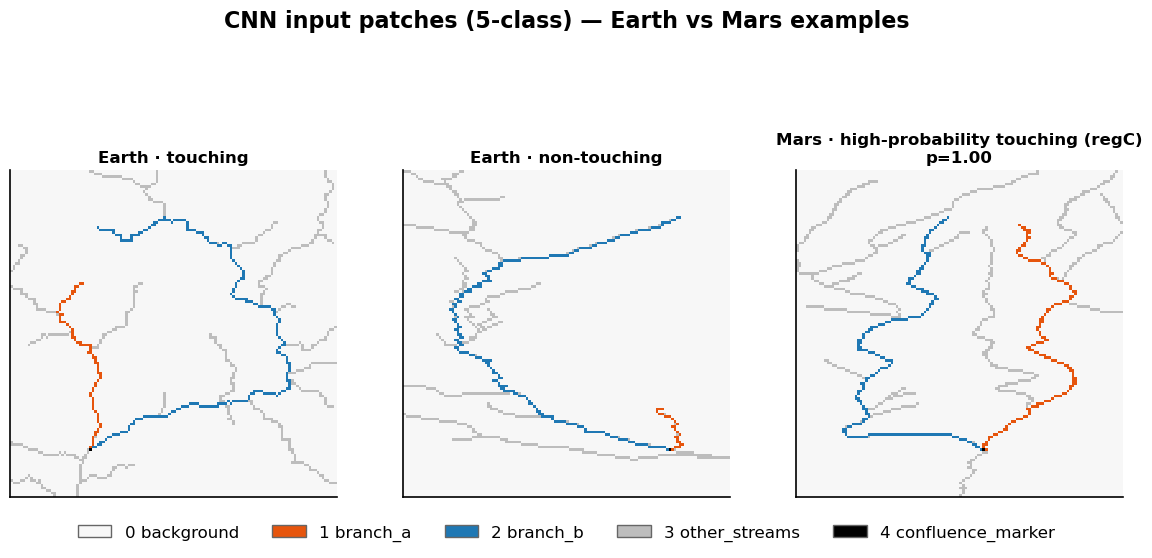

In [8]:
fid = "04_cnn_patch_examples"
sources = []
try:
    examples = []
    idx_path = paths.MARS_CNN_PATCH_INDEX
    mds_path = paths.RESULTS_DIR / "master_dataset_v4_cnn_full.csv"
    sources += [mds_path, idx_path]

    def _load_patch(rel):
        fp = resolve(rel)
        return np.load(fp) if fp and fp.exists() else None

    def _pick_complex(sub, n_scan=150):
        best, best_score = None, -1
        for rp in sub["raster_path"].dropna().head(n_scan):
            p = _load_patch(rp)
            if p is None:
                continue
            score = int((p == OTHER_STREAMS).sum()) + int((p > 0).sum()) // 4
            if score > best_score:
                best, best_score = p, score
        return best

    if mds_path.exists():
        mds = pd.read_csv(mds_path, usecols=["raster_path", "y", "basin"])
        et = _pick_complex(mds[(mds["y"] == 1) & mds["raster_path"].notna()])
        en = _pick_complex(mds[(mds["y"] == 0) & mds["raster_path"].notna()])
        if et is not None:
            examples.append(("Earth · touching", et))
        if en is not None:
            examples.append(("Earth · non-touching", en))
    else:
        print("[missing artifact]", mds_path)

    if idx_path.exists():
        pidx = pd.read_parquet(idx_path)[["pair_id", "patch_path"]]
        if PRED is not None:  # Mars high-probability touching pair (regC)
            pp = PRED.merge(pidx, on="pair_id", how="left")
            for _, r in pp[pp["prob_touching"] >= HIGH_CONF_PROB].sort_values(
                    "prob_touching", ascending=False).iterrows():
                patch = _load_patch(r["patch_path"])
                if patch is not None:
                    examples.append((f"Mars · high-probability touching (regC)\n"
                                     f"p={r['prob_touching']:.2f}", patch))
                    break
    else:
        print("[missing artifact]", idx_path)

    if not examples:
        raise RuntimeError("no CNN patch examples could be loaded")

    n = len(examples)
    fig, axes = plt.subplots(1, n, figsize=(4.0 * n, 4.8))
    axes = np.atleast_1d(axes).ravel()
    for ax, (t, patch) in zip(axes, examples):
        plot_5class_patch(ax, patch, t)
    fig.legend(handles=patch_legend_handles(), loc="lower center", ncol=5,
               frameon=False, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("CNN input patches (5-class) — Earth vs Mars examples",
                 fontsize=16, fontweight="bold", y=1.12)
    fig.tight_layout(rect=(0, 0.06, 1, 0.92))
    outs = export(fig, fid)
    record(fid, "CNN patch examples",
           "5-class CNN patches: Earth touching, Earth non-touching, and a "
           "high-probability Mars touching pair (regC).",
           "Methods", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid, "| examples:", n)
except Exception as e:
    record(fid, "CNN patch examples", "5-class CNN patch grid.",
           "Methods", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 5 · Feature distributions

The five production geometric features as touching-vs-non-touching distributions
on labelled Earth pairs (clean histograms; the geometric definitions are in the
separate schematic below).

ok 05_feature_explanation_panel


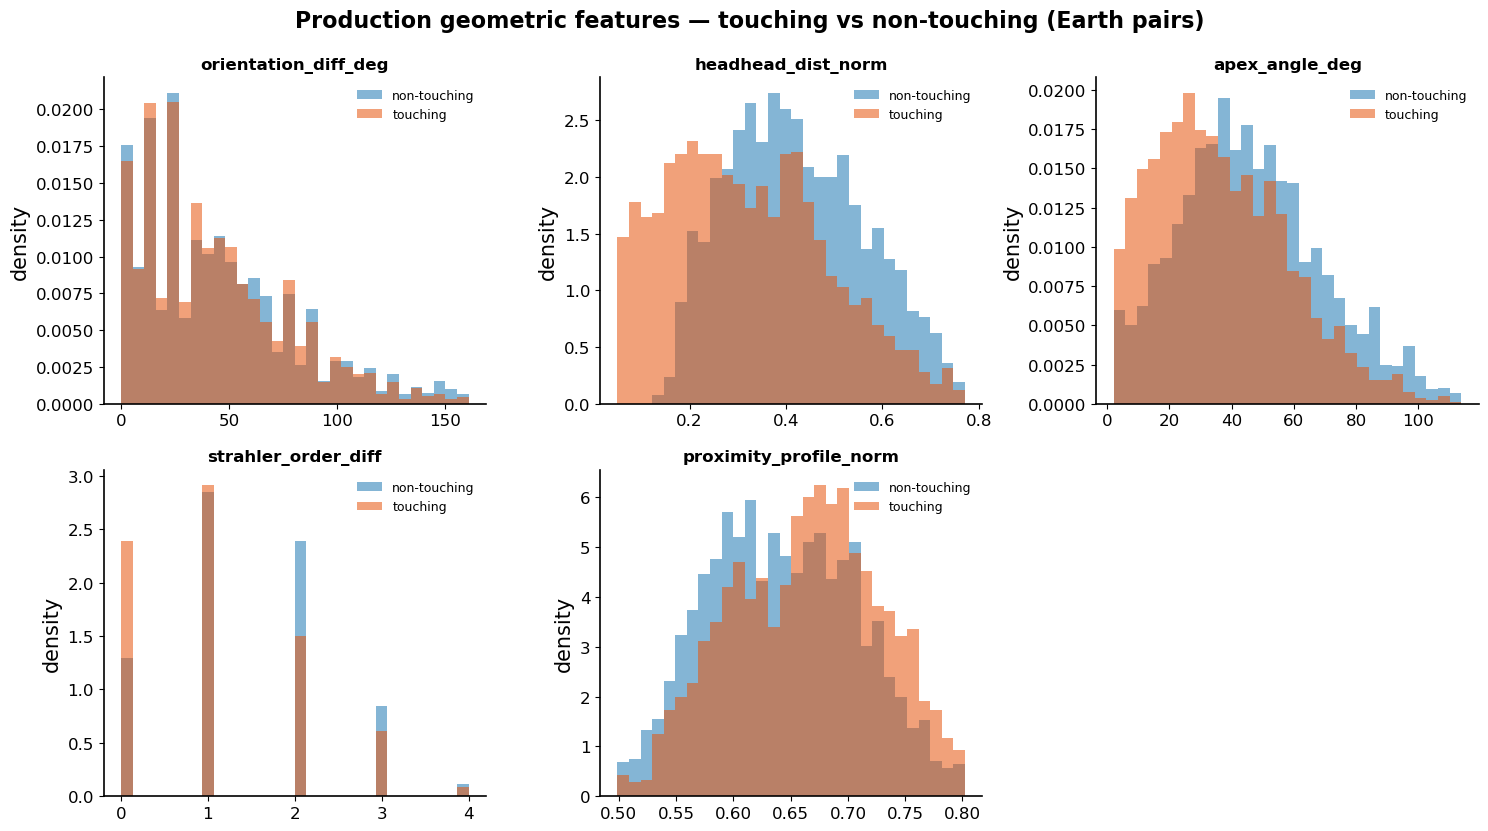

In [9]:
fid = "05_feature_explanation_panel"
sources = []
try:
    mds_path = paths.RESULTS_DIR / "master_dataset_v4_cnn_full.csv"
    sources = [mds_path]
    if not mds_path.exists():
        raise FileNotFoundError(mds_path)
    keep = ["y"] + poster.PRODUCTION_GEOM_FEATURES
    df = pd.read_csv(mds_path, usecols=lambda c: c in keep)
    fig = feature_distribution_panel(df, label_col="y", include_schematic=False)
    outs = export(fig, fid)
    record(fid, "Feature distributions",
           "Touching vs non-touching distributions for the five production "
           "geometric features (histograms only).",
           "Methods", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid)
except Exception as e:
    record(fid, "Feature distributions", "Geometric feature distributions.",
           "Methods", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 5b · Feature schematic

A dedicated schematic defining **all five** production geometric features on the
same synthetic two-branch pair: `orientation_diff_deg` (initial downstream flow
azimuths), `headhead_dist_norm` (head–head distance over total path length),
`apex_angle_deg` (angle at the confluence), `strahler_order_diff`, and
`proximity_profile_norm` (how the two channels' gap varies along their length).

ok 05b_feature_schematic


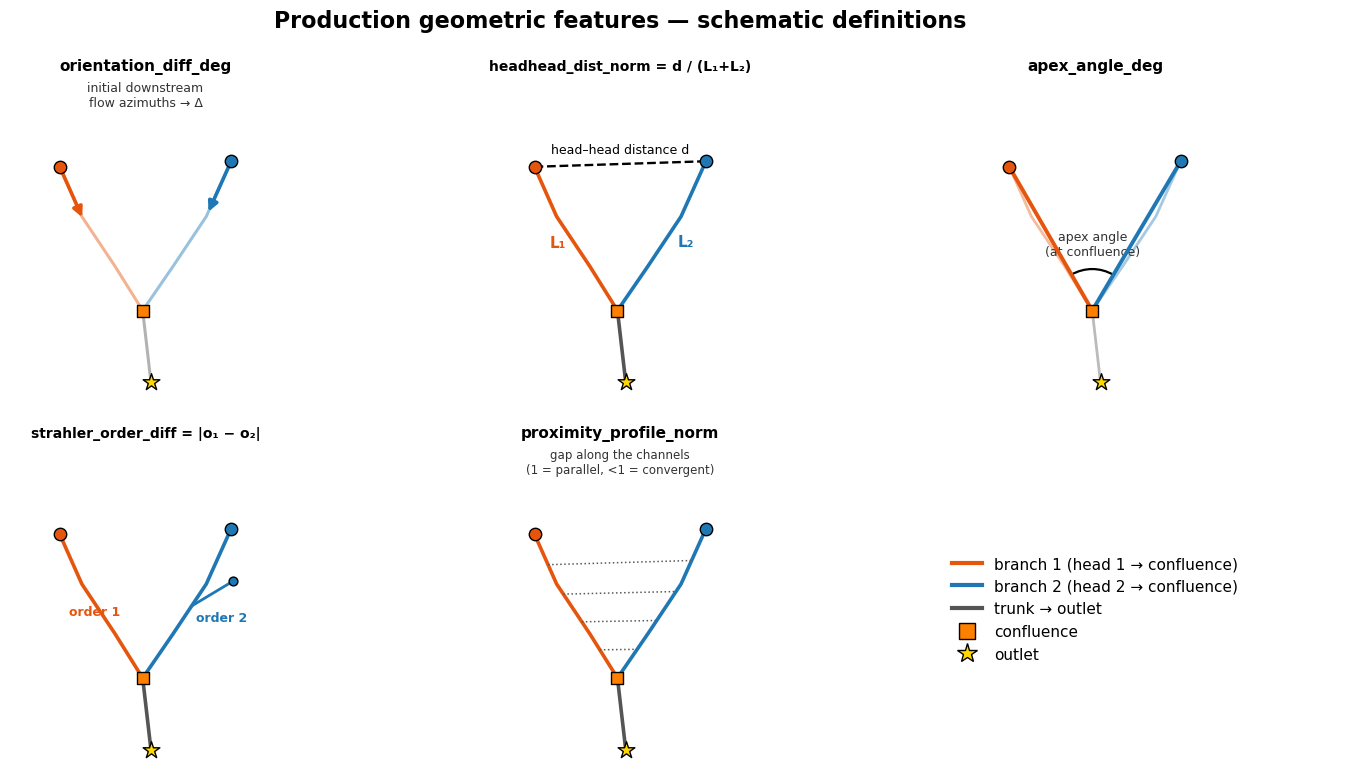

In [10]:
fid = "05b_feature_schematic"
sources = []
try:
    fig = feature_schematic_panel()
    outs = export(fig, fid)
    record(fid, "Feature schematic",
           "Synthetic schematic defining each of the five production geometric "
           "features (orientation, head-head distance, apex angle, Strahler order "
           "difference, proximity profile).",
           "Methods", sources, outs, "generated")
    print("ok", fid)
except Exception as e:
    record(fid, "Feature schematic", "Feature definition schematic.",
           "Methods", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 6 · Earth model validation curves (regime models, regC selected)

ROC and Precision–Recall on the outlet-grouped held-out Earth test split for the
regime `geom+cnn_emb` models. All three regimes are shown for context; **regC is
the selected operating regime**. Inference only — models are loaded, not
retrained.

ok 06_model_validation_curves | regimes: ['regA', 'regB', 'regC (selected)']


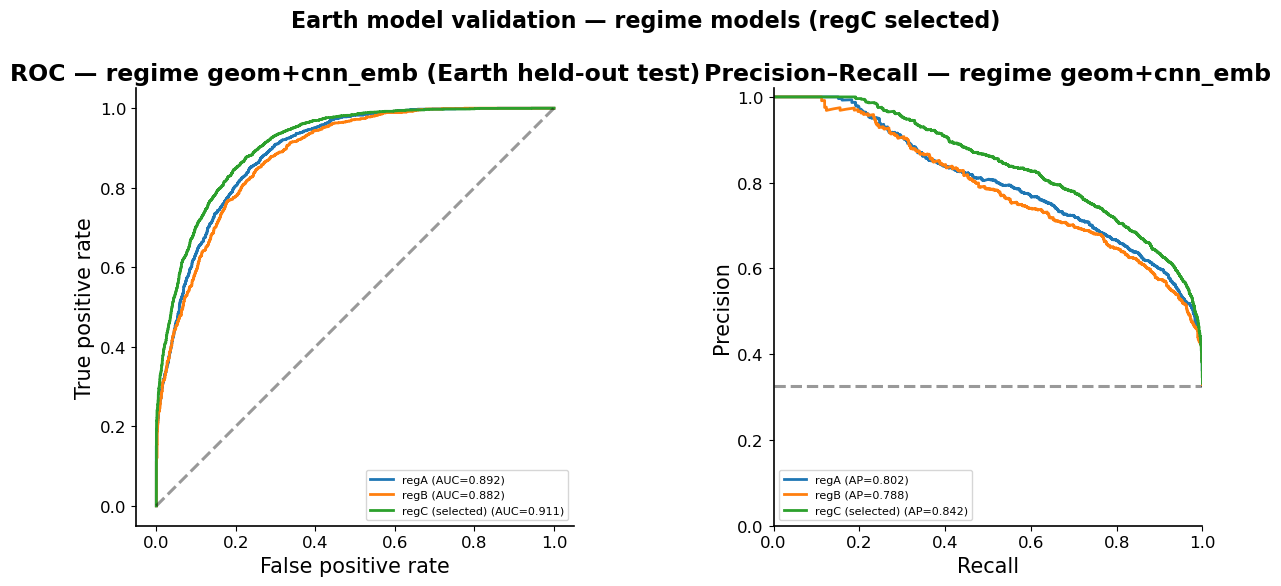

In [11]:
fid = "06_model_validation_curves"
sources = []
try:
    entries = []
    for R in ["regA", "regB", "regC"]:
        csv = paths.RESULTS_DIR / f"master_dataset_{R}_with_emb.csv"
        mp = paths.model_path(f"xgb_geom_plus_cnn_emb_{R}.json")
        fp = paths.model_path(f"feature_columns_geom_plus_cnn_emb_{R}.txt")
        for s in (csv, mp, fp):
            if s not in sources:
                sources.append(s)
        if csv.exists() and mp.exists() and fp.exists():
            y, proba, _ = holdout_split_predict(csv, mp, fp)
            label = f"{R} (selected)" if R == SELECTED_REGIME else R
            entries.append((label, y, proba))
        else:
            print("[missing artifact] skipping regime", R)
    if not entries:
        raise RuntimeError("no regime dataset/model pairs available")

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    roc_curve_panel(axes[0], entries, "ROC — regime geom+cnn_emb (Earth held-out test)")
    pr_curve_panel(axes[1], entries, "Precision–Recall — regime geom+cnn_emb")
    fig.suptitle(f"Earth model validation — regime models ({SELECTED_REGIME} selected)",
                 fontsize=16, fontweight="bold")
    fig.tight_layout()
    outs = export(fig, fid)
    record(fid, "Model validation curves (regC)",
           "ROC + PR on the held-out Earth test split for regime geom+cnn_emb "
           "models; regC is the selected regime.",
           "Results", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid, "| regimes:", [e[0] for e in entries])
except Exception as e:
    record(fid, "Model validation curves (regC)", "ROC/PR curves.",
           "Results", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 7 · Earth model comparison bars

ROC-AUC, PR-AUC and F1 on the **same outlet-grouped held-out test split** used by
the validation curves above, read from the per-model metrics CSVs
(`combined_models_comparison.csv`, `xgb_geom_plus_cnn_emb_reg{A,B,C}_metrics.csv`).
So regC's ROC-AUC here matches the curve in §6 (≈0.91). *Note: the older
`ALL_MODELS_METRICS.csv` reported ~0.88 for regC because it used a different
evaluation protocol; this figure deliberately uses the held-out-test numbers for
consistency.*

ok 07_model_comparison_bar | regC roc_auc: 0.9108552767169514


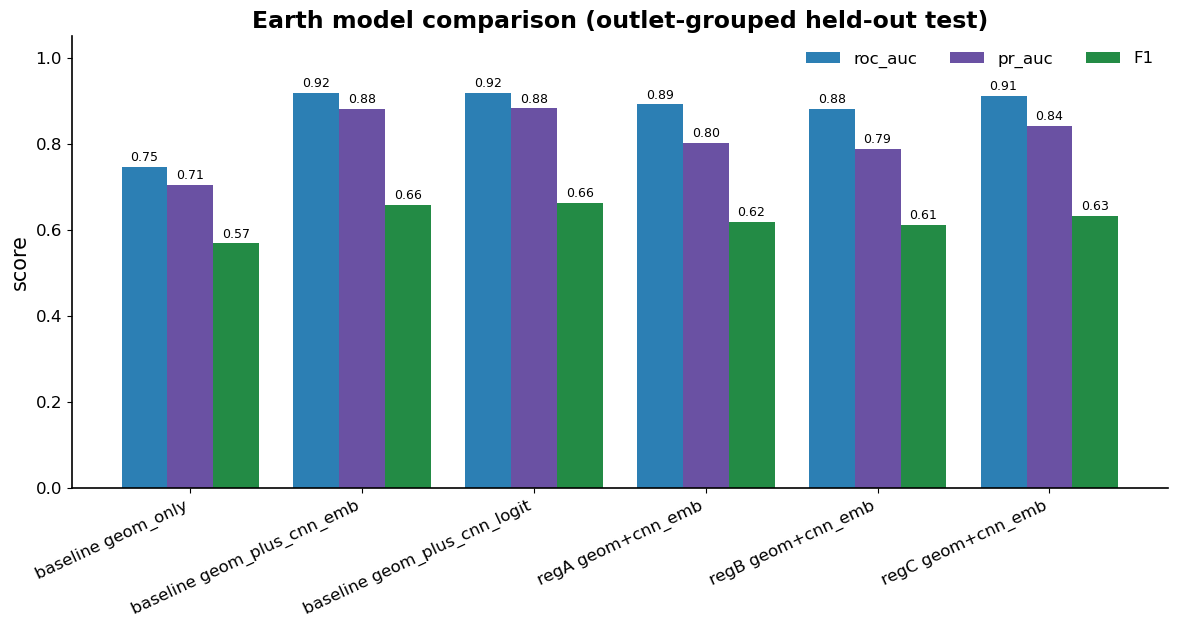

In [12]:
fid = "07_model_comparison_bar"
sources = []
try:
    # Source the SAME held-out-test metrics that Fig 6 recomputes (the training
    # per-model metrics CSVs), so the two figures are consistent. (The earlier
    # ALL_MODELS_METRICS.csv used a different evaluation protocol — see note.)
    rows = []
    ccm = paths.MODELS_DIR / "combined_models_comparison.csv"
    sources.append(ccm)
    if ccm.exists():
        for _, r in pd.read_csv(ccm).iterrows():
            rows.append({"model": f"baseline {r['variant']}",
                         "roc_auc": r["roc_auc_test"], "pr_auc": r["pr_auc_test"],
                         "F1": r["f1_tuned"]})
    for R in ["regA", "regB", "regC"]:
        mp = paths.MODELS_DIR / f"xgb_geom_plus_cnn_emb_{R}_metrics.csv"
        sources.append(mp)
        if mp.exists():
            m = pd.read_csv(mp).iloc[0]
            rows.append({"model": f"{R} geom+cnn_emb",
                         "roc_auc": m["roc_auc_test"], "pr_auc": m["pr_auc_test"],
                         "F1": m["f1_tuned"]})
    if not rows:
        raise FileNotFoundError("no per-model held-out metrics CSVs found")
    metrics = pd.DataFrame(rows)
    fig = model_comparison_bars(
        metrics, label_col="model", metric_cols=("roc_auc", "pr_auc", "F1"),
        title="Earth model comparison (outlet-grouped held-out test)")
    outs = export(fig, fid)
    record(fid, "Model comparison bar",
           "ROC-AUC / PR-AUC / F1 on the held-out test split (same protocol as "
           "the validation curves) for baseline + regime variants.",
           "Results", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid, "| regC roc_auc:",
          float(metrics.loc[metrics.model == "regC geom+cnn_emb", "roc_auc"].iloc[0]))
except Exception as e:
    record(fid, "Model comparison bar", "Model comparison bars.",
           "Results", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 8 · Mars prediction summary (regC)

regC prediction totals (scored pairs, predicted touching, high-confidence) beside
the touching and high-confidence fractions for each regime, with **regC**
highlighted. Computed directly from the regime prediction files
(`mars_combined_reg{A,B,C}_predictions.csv`) so all counts share one definition:
touching = the regime's own decision, high-confidence = `prob ≥ 0.90` (above the
~0.81 regC threshold).

ok 08_mars_prediction_summary | totals: {'n_pairs': 3682, 'n_touching': 1714, 'n_high_conf': 996}


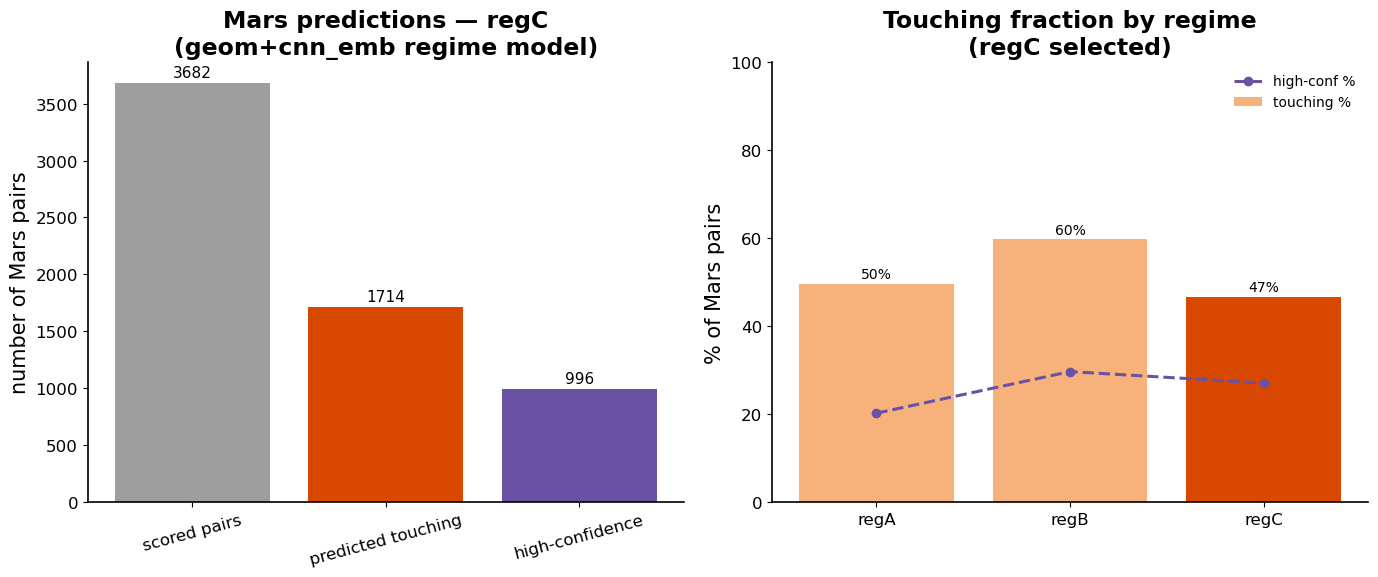

In [13]:
fid = "08_mars_prediction_summary"
sources = []
try:
    # Build the summary directly from the regime prediction files so every count
    # uses the SAME definitions: touching = the regime's own decision
    # (pred_touching), high-confidence = prob >= HIGH_CONF_PROB (above threshold).
    reg_pred = {}
    for R in ["regA", "regB", "regC"]:
        p = paths.MARS_MODEL_OUTPUTS_DIR / f"mars_combined_{R}_predictions.csv"
        sources.append(p)
        if p.exists():
            reg_pred[R] = pd.read_csv(p, usecols=["pred_touching", "prob_touching"])
    if SELECTED_REGIME not in reg_pred:
        raise FileNotFoundError(f"{SELECTED_REGIME} predictions missing")

    hc_col = f"high_conf_frac_ge{HIGH_CONF_PROB:.2f}"
    interp_df = pd.DataFrame([
        {"regime": R,
         "touching_frac": float((p["pred_touching"] == 1).mean()),
         hc_col: float((p["prob_touching"] >= HIGH_CONF_PROB).mean())}
        for R, p in reg_pred.items()
    ])
    pc = reg_pred[SELECTED_REGIME]
    totals = {
        "n_pairs": int(len(pc)),
        "n_touching": int((pc["pred_touching"] == 1).sum()),
        "n_high_conf": int((pc["prob_touching"] >= HIGH_CONF_PROB).sum()),
    }
    fig = mars_regime_summary_panel(totals, interp_df, selected_regime=SELECTED_REGIME)
    outs = export(fig, fid)
    record(fid, "Mars prediction summary (regC)",
           f"regC totals + per-regime touching and high-confidence (prob>="
           f"{HIGH_CONF_PROB:.2f}) fractions, consistent definitions; regC selected.",
           "Results", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid, "| totals:", totals)
except Exception as e:
    record(fid, "Mars prediction summary (regC)", "Mars prediction summary.",
           "Results", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 9 · Mars prediction maps (selected basins, regC)

Representative regC networks (dense / simple / high-confidence-rich) with
predicted-touching pairs highlighted (high-confidence stronger). The combined
montage is shown inline; **per-basin numbered maps** — where each channel head
gets a unique `C#` id and the legend lists the predicted pairs sorted by
probability as `Pair k: Ca – Cb, p=…` — are written under
`data/results/poster_figures/mars_prediction_maps/`, and one is shown inline.

selected networks: {'dense': 1, 'simple': 12, 'high_confidence': 148}


ok 09_mars_prediction_maps_selected_basins


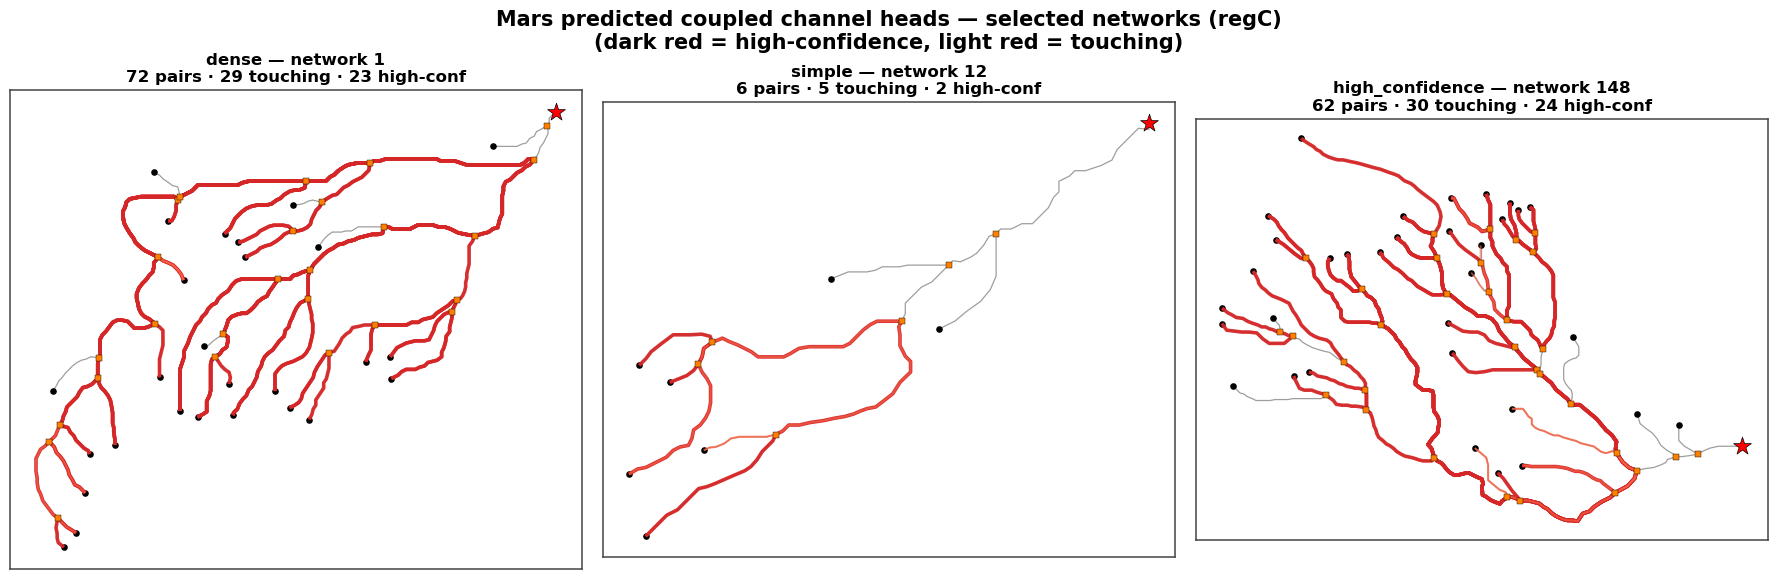

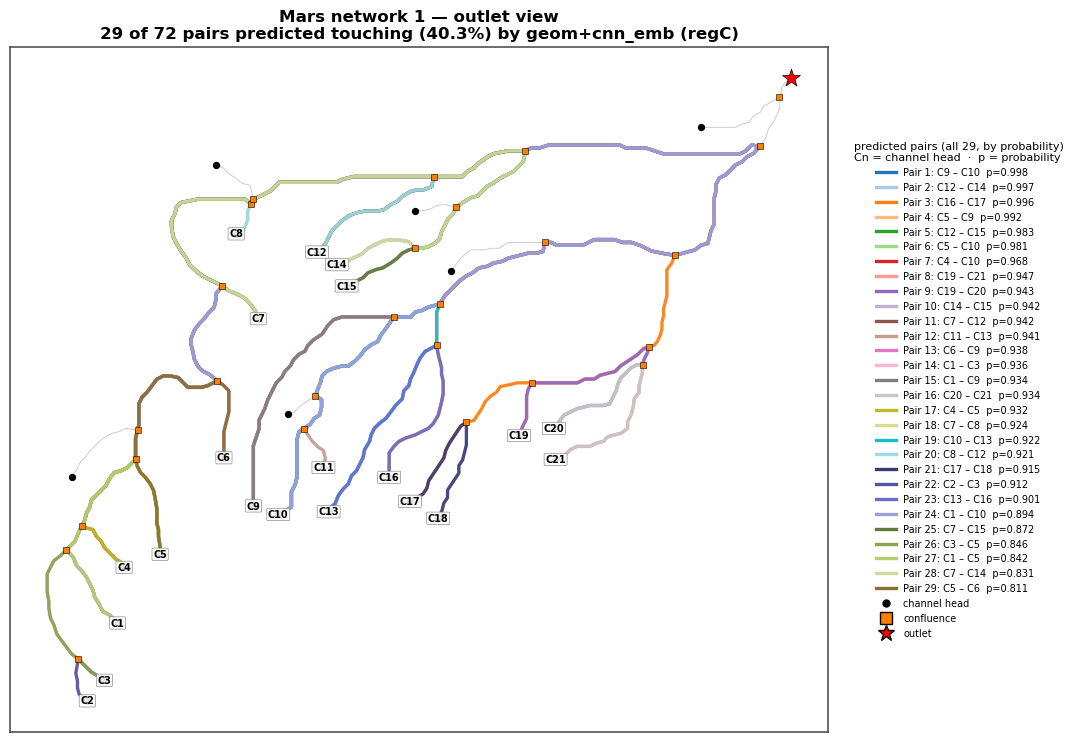

In [14]:
fid = "09_mars_prediction_maps_selected_basins"
sources = []
try:
    sources = [paths.MARS_TOPOLOGY_GPKG, paths.MARS_PAIRS_GPKG,
               paths.MARS_MODEL_OUTPUTS_DIR / f"mars_combined_{SELECTED_REGIME}_predictions.csv"]
    if PRED is None or not segs_by_nid or not paths_lookup:
        raise RuntimeError("Mars regC predictions / topology / pair paths unavailable")

    picks = select_representative_networks(
        PRED, pred_col="pred_touching", prob_col="prob_touching",
        disagreement_col="__absent__")
    picks = {c: n for c, n in picks.items() if n in segs_by_nid}
    print("selected networks:", picks)

    outs = []
    # Per-basin numbered maps (note 7): colour + number per pair, full pair list.
    for cat, nid in picks.items():
        dfn = PRED[PRED["network_id"] == nid]
        single = render_outlet_touching_pairs(
            nid, dfn, segs_by_nid[nid], nodes_by_nid[nid], outlets_by_nid.get(nid),
            paths_lookup, touching_col="pred_touching", prob_col="prob_touching",
            model_name=f"geom+cnn_emb ({SELECTED_REGIME})", number_heads=True,
            output=None)
        if single is not None:
            w = save_figure(single, MARS_MAPS_DIR,
                            f"mars_net{nid:03d}_{cat}_{SELECTED_REGIME}",
                            formats=("svg", "png"), close=True)
            outs += list(w.values())

    # Combined montage (overview; touching = red, high-conf = dark red).
    n = len(picks)
    ncols = min(n, 3)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.0, nrows * 6.0))
    axes = np.atleast_1d(axes).ravel()
    for ax, (cat, nid) in zip(axes, picks.items()):
        dfn = PRED[PRED["network_id"] == nid]
        plot_network_overview(ax, segs_by_nid[nid], nodes_by_nid[nid],
                              outlets_by_nid.get(nid))
        touch = dfn[dfn["pred_touching"] == 1]
        n_hc = int((dfn["prob_touching"] >= HIGH_CONF_PROB).sum())
        for _, r in touch.iterrows():
            strong = r["prob_touching"] >= HIGH_CONF_PROB
            for b in ("A", "B"):
                path = paths_lookup.get((str(r["pair_id"]), b))
                if path is not None:
                    gpd.GeoSeries([path]).plot(
                        ax=ax, color="#d62728" if strong else "#fb6a4a",
                        linewidth=2.6 if strong else 1.4,
                        alpha=0.95 if strong else 0.6, zorder=4)
        ax.set_title(f"{cat} — network {nid}\n{len(dfn)} pairs · {len(touch)} "
                     f"touching · {n_hc} high-conf", fontsize=12)
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle(f"Mars predicted coupled channel heads — selected networks "
                 f"({SELECTED_REGIME})\n(dark red = high-confidence, light red = touching)",
                 fontsize=15, fontweight="bold")
    fig.tight_layout()
    outs += export(fig, fid)

    # Inline numbered example (the densest pick).
    show_nid = picks.get("dense") or next(iter(picks.values()))
    demo = render_outlet_touching_pairs(
        show_nid, PRED[PRED["network_id"] == show_nid], segs_by_nid[show_nid],
        nodes_by_nid[show_nid], outlets_by_nid.get(show_nid), paths_lookup,
        touching_col="pred_touching", prob_col="prob_touching",
        model_name=f"geom+cnn_emb ({SELECTED_REGIME})", number_heads=True, output=None)

    record(fid, "Mars prediction maps (selected basins, regC)",
           "regC networks with predicted-touching pairs highlighted; per-basin "
           "numbered maps (pairs identifiable) exported.",
           "Results", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid)
except Exception as e:
    record(fid, "Mars prediction maps (selected basins, regC)", "Mars prediction maps.",
           "Results", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 10 · High-confidence contact sheet (regC)

**Five** regC touching pairs sampled across the probability range **p = 1.00 →
0.80** (not just the top five), so the sheet shows what a confident prediction
looks like at different probability levels.

ok 10_high_confidence_contact_sheet | pool>=0.80: 1787 | shown: 5 | probs: [0.999, 0.949, 0.899, 0.85, 0.8]


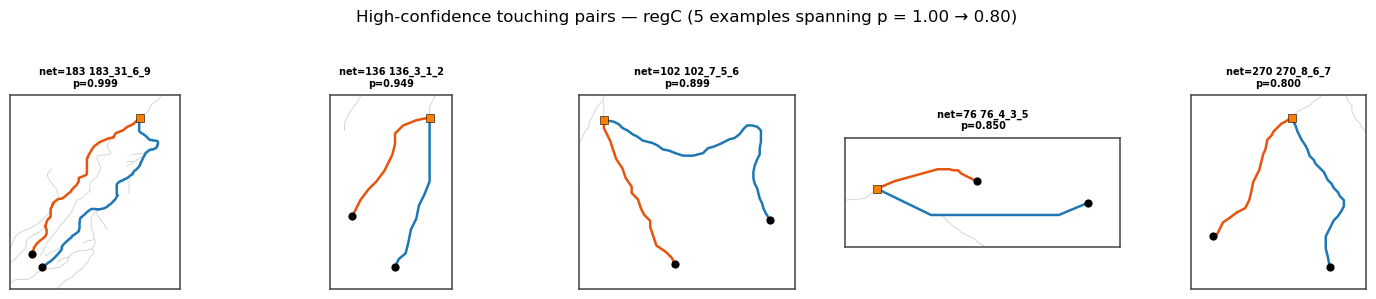

In [15]:
fid = "10_high_confidence_contact_sheet"
sources = []
try:
    sources = [paths.MARS_TOPOLOGY_GPKG, paths.MARS_PAIRS_GPKG,
               paths.MARS_MODEL_OUTPUTS_DIR / f"mars_combined_{SELECTED_REGIME}_predictions.csv"]
    if PRED is None or not nodes_by_nid or not paths_lookup:
        raise RuntimeError("Mars regC predictions / topology / pair paths unavailable")
    # 5 examples spanning the probability range p = 1.00 → 0.80 (not just the top).
    LOW = 0.80
    pool = PRED[PRED["prob_touching"] >= LOW].copy()
    targets = np.linspace(float(pool["prob_touching"].max()), LOW, 5)
    sel_idx: list = []
    for t in targets:
        cand = pool[~pool.index.isin(sel_idx)]
        if cand.empty:
            break
        sel_idx.append((cand["prob_touching"] - t).abs().idxmin())
    sel = pool.loc[sel_idx].sort_values("prob_touching", ascending=False)
    fig = render_contact_sheet(
        sel, nodes_by_nid, segs_by_nid, outlets_by_nid, paths_lookup,
        title=f"High-confidence touching pairs — {SELECTED_REGIME} "
              f"(5 examples spanning p = 1.00 → {LOW:.2f})",
        subtitle_fn=lambda r: (f"net={int(r['network_id'])} {r['pair_id']}\n"
                               f"p={r['prob_touching']:.3f}"),
        output=None, cols=5)
    if fig is None:
        raise RuntimeError("no high-confidence pairs to render")
    outs = export(fig, fid)
    record(fid, "High-confidence contact sheet (regC)",
           "5 regC touching pairs spanning probability 1.00 -> 0.80.",
           "Results", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid, "| pool>=0.80:", len(pool), "| shown:", len(sel),
          "| probs:", [round(p, 3) for p in sel["prob_touching"]])
except Exception as e:
    record(fid, "High-confidence contact sheet (regC)", "High-confidence contact sheet.",
           "Results", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 11 · Disagreement contact sheet (baseline combined)

The 20 strongest emb-vs-logit disagreement pairs from the **baseline combined**
inference — disagreement is only defined where two models are compared, so this
figure stays on the baseline rather than the single regC model.

ok 11_disagreement_contact_sheet | pool: 2042


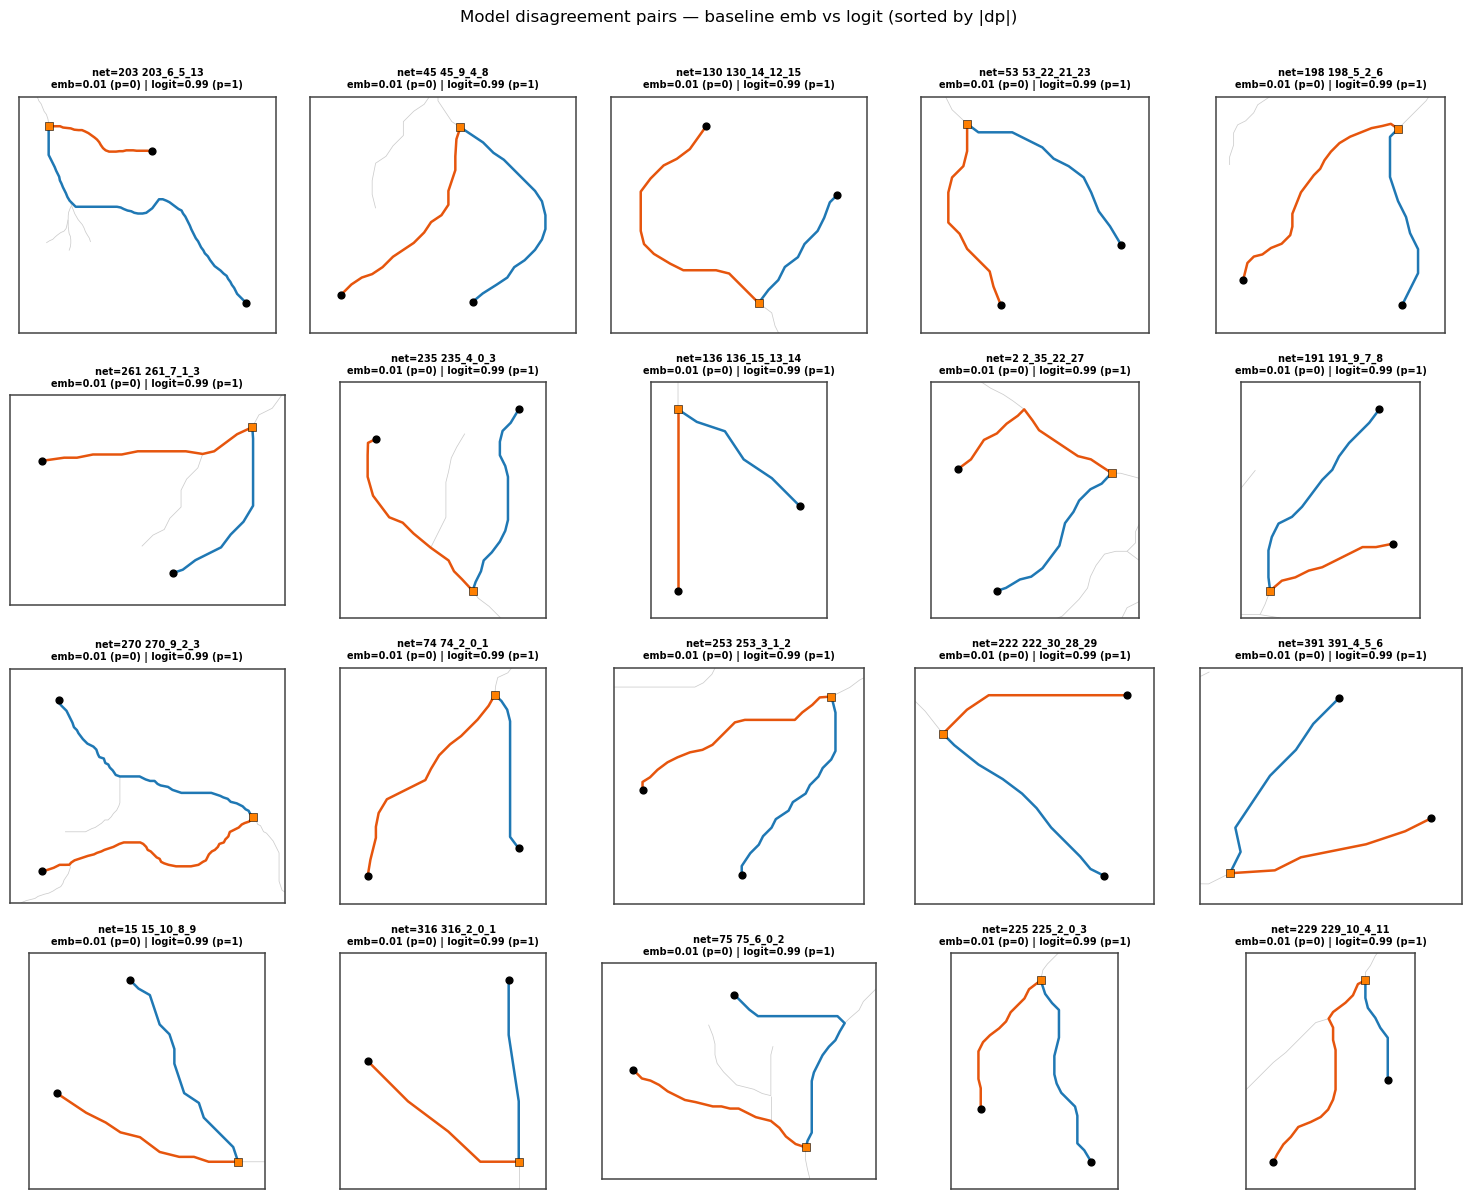

In [16]:
fid = "11_disagreement_contact_sheet"
sources = []
try:
    sources = [paths.MARS_TOPOLOGY_GPKG, paths.MARS_PAIRS_GPKG,
               paths.MARS_MODEL_OUTPUTS_DIR / "mars_combined_model_predictions.parquet"]
    if PRED_BASE is None or not nodes_by_nid or not paths_lookup:
        raise RuntimeError("Baseline combined predictions / topology unavailable")
    dis = PRED_BASE[PRED_BASE["emb_logit_disagreement"] == 1].copy()
    if dis.empty:
        raise RuntimeError("no disagreement pairs available")
    dis["abs_dp"] = (dis["prob_touching_emb"] - dis["prob_touching_logit"]).abs()
    dis = dis.sort_values("abs_dp", ascending=False).head(20)
    fig = render_contact_sheet(
        dis, nodes_by_nid, segs_by_nid, outlets_by_nid, paths_lookup,
        title="Model disagreement pairs — baseline emb vs logit (sorted by |dp|)",
        subtitle_fn=lambda r: (f"net={int(r['network_id'])} {r['pair_id']}\n"
                               f"emb={r['prob_touching_emb']:.2f} "
                               f"(p={int(r['pred_touching_emb'])}) | "
                               f"logit={r['prob_touching_logit']:.2f} "
                               f"(p={int(r['pred_touching_logit'])})"),
        output=None)
    if fig is None:
        raise RuntimeError("no disagreement pairs to render")
    outs = export(fig, fid)
    record(fid, "Disagreement contact sheet (baseline)",
           "20 strongest baseline emb-vs-logit disagreement pairs.",
           "Discussion", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid, "| pool:", int((PRED_BASE['emb_logit_disagreement'] == 1).sum()))
except Exception as e:
    record(fid, "Disagreement contact sheet (baseline)", "Disagreement contact sheet.",
           "Discussion", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 12 · Drainage density & regime calibration

Earth drainage density vs stream-extraction threshold with the Mars median Dd
reference and the three selected regime thresholds (regC selected). Cached sweep
outputs only.

ok 12_drainage_density_regime_calibration | Mars Dd: 0.224 | regimes: {'regA': 0.2, 'regB': 0.25, 'regC': 0.15}


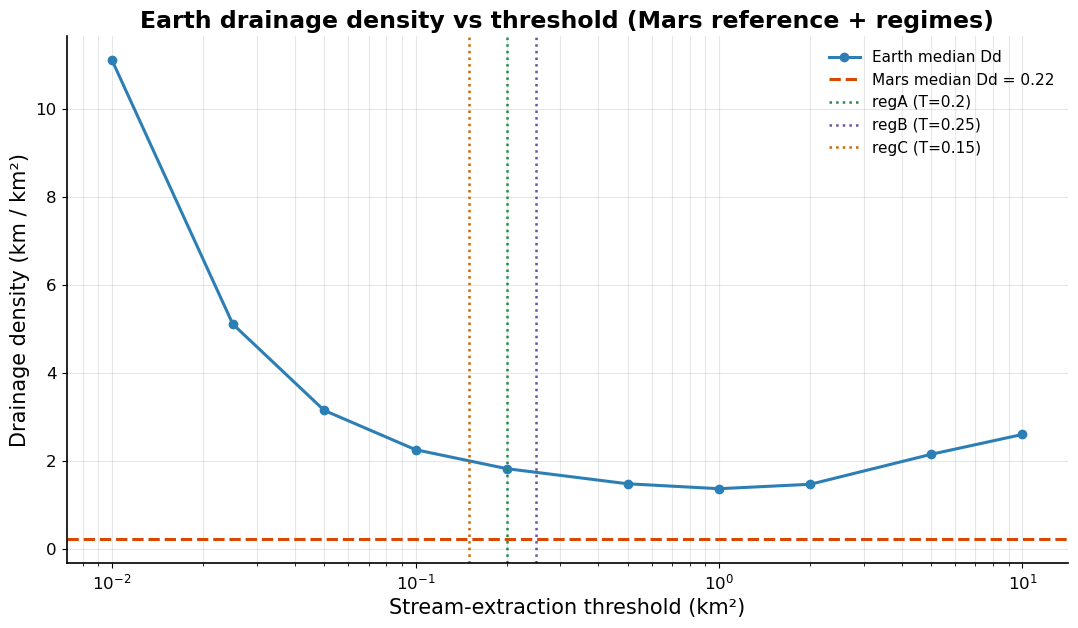

In [17]:
fid = "12_drainage_density_regime_calibration"
sources = []
try:
    dd_dir = paths.RESULTS_DIR / "drainage_density_calibration" / "complexity_calibration"
    sweep_path = dd_dir / "dd_hull_match_vs_mars_summary.csv"
    post_path = dd_dir / "post_optimization_summary.csv"
    sources = [sweep_path, post_path]
    if not sweep_path.exists():
        raise FileNotFoundError(sweep_path)
    sweep = pd.read_csv(sweep_path)

    mars_dd = None
    if post_path.exists():
        post = pd.read_csv(post_path)
        row = post[post["metric"].str.contains("Dd_hull median", na=False)]
        if not row.empty:
            mars_dd = float(row["Mars"].iloc[0])
    regime_thr = {name: reg.threshold_km2 for name, reg in REGIMES.items()}

    fig = drainage_density_regime_panel(
        sweep, threshold_col="threshold_km2", earth_dd_col="full_dd_med",
        mars_dd_median=mars_dd, regime_thresholds=regime_thr,
        title="Earth drainage density vs threshold (Mars reference + regimes)")
    outs = export(fig, fid)
    record(fid, "Drainage density & regime calibration",
           "Earth Dd vs extraction threshold with Mars median reference and the "
           "selected regime thresholds.",
           "Methods", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid, "| Mars Dd:", mars_dd, "| regimes:", regime_thr)
except Exception as e:
    record(fid, "Drainage density & regime calibration", "DD regime calibration.",
           "Methods", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 12b · Regime parameters (verified from the code)

The exact extraction parameters, read from `channel_heads.regimes.REGIMES`,
`channel_heads.pruning.apply_strategy` and the baseline `th145` setup — **not**
assumed from the poster text. Threshold cells are computed for the comparison
basin's pixel size. (`pre_remove_max_order=1` → drop 1st-order;
`order_gap_to_prune=0` → no delta pruning.)

In [18]:
REGIME_COMPARE_BASIN = "sakhalin"   # one representative basin (large outlet)
EARTH_VARIANTS = None
cmp_dem = None
regime_params = None
try:
    from channel_heads.pipelines import build_earth_network_variants, trim_description

    cmp_dem, cmp_px, EARTH_VARIANTS = build_earth_network_variants(REGIME_COMPARE_BASIN)
    regime_params = pd.DataFrame([
        {
            "setup": v.label,
            "threshold_km2": round(v.threshold_km2, 3),
            "threshold_cells_px": int(v.threshold_cells),
            "trimming": trim_description(v.pre_remove_max_order),
            "order_gap_pruning": "none" if v.order_gap_to_prune == 0
                                 else f">={v.order_gap_to_prune}",
            "channel_heads_total": 0 if v.s is None
                                   else int(v.s.streampoi("channelheads").sum()),
        }
        for v in EARTH_VARIANTS
    ])
    regime_params.to_csv(POSTER_DIR / "regime_parameters.csv", index=False)
    print(f"Regime parameters (basin={REGIME_COMPARE_BASIN}, pixel={cmp_px:.1f} m):")
    print(regime_params.to_string(index=False))
except Exception as e:
    print("[regime table skipped]", repr(e))
regime_params

Regime parameters (basin=sakhalin, pixel=76.3 m):
   setup  threshold_km2  threshold_cells_px       trimming order_gap_pruning  channel_heads_total
Baseline          0.844                 145           none              none                  234
    regA          0.200                  34 drop 1st-order              none                  185
    regB          0.250                  43 drop 1st-order              none                  144
    regC          0.150                  26 drop 1st-order              none                  250


,setup,threshold_km2,threshold_cells_px,trimming,order_gap_pruning,channel_heads_total
0,Baseline,0.844,145,none,none,234
1,regA,0.200,34,drop 1st-order,none,185
2,regB,0.250,43,drop 1st-order,none,144
3,regC,0.150,26,drop 1st-order,none,250


## 12c · Same basin under the three regimes

The same large outlet of the representative basin, extracted under **regA, regB,
regC**, to show how the threshold / trimming / order-gap choices change network
complexity (baseline parameters are in the table above). Streams in blue; each
panel is titled with the exact settings, the channel-head count in view and the
in-view drainage density.

ok 12b_regime_network_comparison


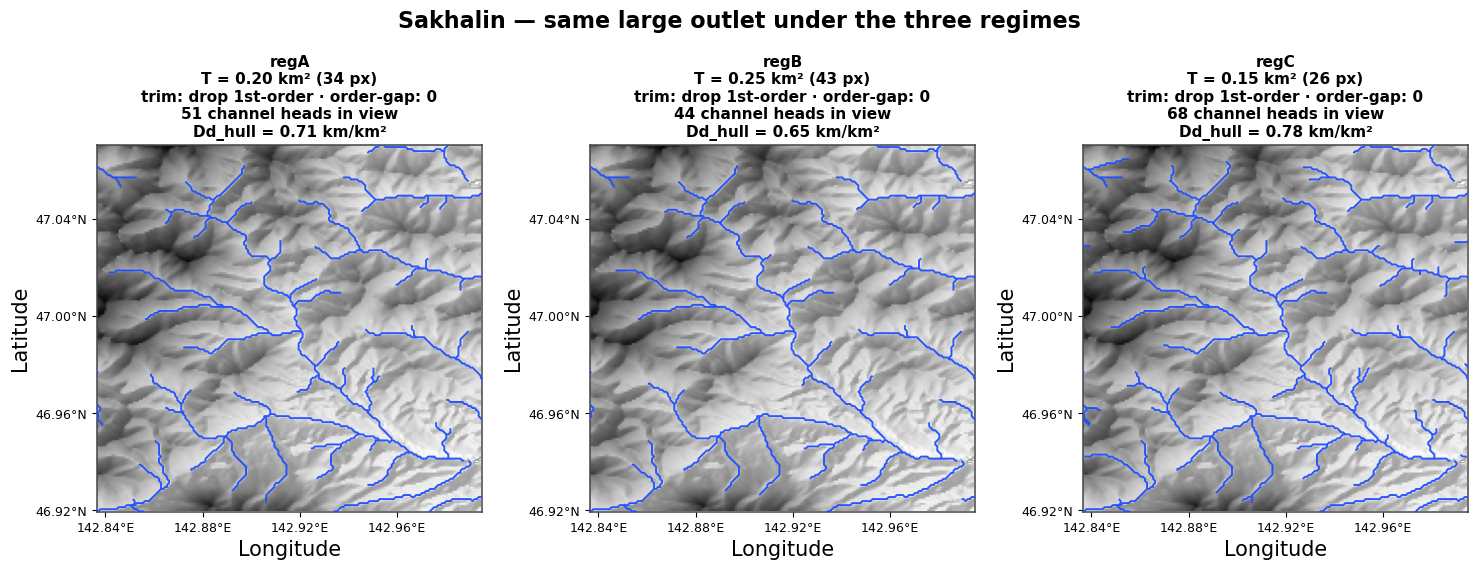

In [19]:
fid = "12b_regime_network_comparison"
sources = [paths.EXAMPLE_DEMS.get(REGIME_COMPARE_BASIN)]
try:
    from channel_heads.viz import largest_outlet_bbox, plot_network_complexity_comparison

    if EARTH_VARIANTS is None or cmp_dem is None:
        raise RuntimeError("regime network variants unavailable (TopoToolbox build failed)")
    # Same spatial extent (the baseline's largest outlet), but show only the
    # three regimes — baseline parameters are in the table above (§12b).
    bbox = largest_outlet_bbox(EARTH_VARIANTS[0].s, pad_frac=0.05)
    regime_variants = [v for v in EARTH_VARIANTS if v.label != "Baseline"]
    fig = plot_network_complexity_comparison(
        cmp_dem, regime_variants, bbox=bbox, pixel_size_m=cmp_px,
        geographic_axes=True)
    fig.suptitle(
        f"{REGIME_COMPARE_BASIN.title()} — same large outlet under the three regimes",
        fontsize=16, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    outs = export(fig, fid)
    record(fid, "Regime network comparison",
           "One basin's largest outlet under regA / regB / regC — how the "
           "threshold (and 1st-order trimming) change extracted network complexity.",
           "Methods", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid)
except Exception as e:
    record(fid, "Regime network comparison", "Regime network comparison.",
           "Methods", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 13 · Main result synthesis (regC)

The candidate hero figure: one **simpler** regC Mars network (few pairs, a handful
predicted touching) shown three ways — raw network → candidate head pairs (model
input) → predicted coupled channel heads. Panel 3 uses the same scheme as §9:
unique `C#` channel-head ids and a probability-sorted pair list
(`Pair k: Ca – Cb, p=…`).

ok 13_main_result_synthesis | network: 230


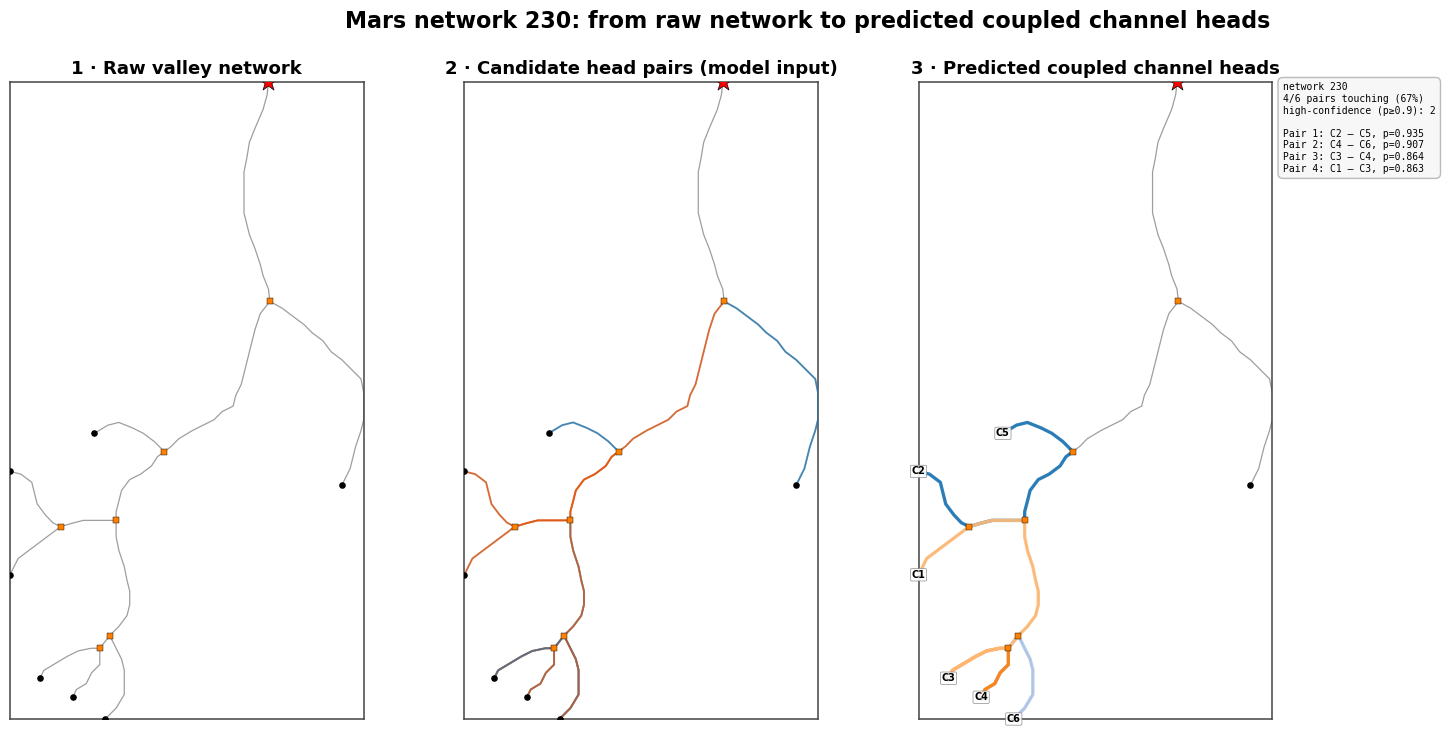

In [20]:
fid = "13_main_result_synthesis"
sources = []
try:
    sources = [paths.MARS_TOPOLOGY_GPKG, paths.MARS_PAIRS_GPKG,
               paths.MARS_MODEL_OUTPUTS_DIR / f"mars_combined_{SELECTED_REGIME}_predictions.csv"]
    if PRED is None or not segs_by_nid or not paths_lookup:
        raise RuntimeError("Mars regC predictions / topology / pair paths unavailable")
    # Prefer a SIMPLER network (few pairs) that still has a handful of touching
    # pairs, so the synthesis + pair list stay clean and readable.
    g = PRED.groupby("network_id")
    summ = pd.DataFrame({
        "n_pairs": g.size(),
        "n_touch": g.apply(lambda d: int((d["pred_touching"] == 1).sum()),
                           include_groups=False),
    })
    summ = summ[summ.index.isin(segs_by_nid)]
    cand = summ[(summ["n_touch"].between(3, 8)) & (summ["n_pairs"].between(6, 18))]
    if cand.empty:
        cand = summ[summ["n_touch"].between(2, 10)]
    pool = cand if not cand.empty else summ
    nid = int(pool.sort_values("n_pairs").index[0])
    dfn = PRED[PRED["network_id"] == nid]
    fig = main_synthesis_figure(
        segs_by_nid[nid], nodes_by_nid[nid], dfn, paths_lookup,
        outlets_by_nid.get(nid), network_id=nid,
        pred_col="pred_touching", prob_col="prob_touching",
        high_conf_prob=HIGH_CONF_PROB)
    outs = export(fig, fid)
    record(fid, "Main result synthesis (regC)",
           "Raw network -> candidate pairs -> predicted coupled channel heads "
           "with a stats box (regC; hero figure).",
           "Results", sources, outs, "generated", missing_inputs(sources))
    print("ok", fid, "| network:", nid)
except Exception as e:
    record(fid, "Main result synthesis (regC)", "Main synthesis figure.",
           "Results", sources, [], "error", [repr(e)])
    print("FAILED", fid, repr(e))

## 14 · Export manifest

Write `poster_figure_manifest.csv` / `.md` and print a final summary.

In [21]:
man = pd.DataFrame(MANIFEST, columns=[
    "figure_id", "title", "purpose", "poster_section",
    "source_artifacts", "output_path", "status", "missing_inputs",
])
csv_path = POSTER_DIR / "poster_figure_manifest.csv"
man.to_csv(csv_path, index=False)

section_order = ["Introduction", "Methods", "Results", "Discussion"]
lines = ["# Poster figure manifest", "",
         f"Generated into `{POSTER_DIR}`.  Selected regime: **{SELECTED_REGIME}**.", ""]
for sec in section_order + sorted(set(man["poster_section"]) - set(section_order)):
    sub = man[man["poster_section"] == sec]
    if sub.empty:
        continue
    lines.append(f"## {sec}")
    lines.append("")
    for _, r in sub.iterrows():
        flag = "OK" if r["status"].startswith("generated") else r["status"].upper()
        lines.append(f"- **{r['figure_id']}** — {r['title']} _({flag})_")
        lines.append(f"  - Caption draft: {r['purpose']}")
        lines.append(f"  - Source: {r['source_artifacts']}")
        if r["missing_inputs"]:
            lines.append(f"  - Missing inputs: {r['missing_inputs']}")
    lines.append("")
md_path = POSTER_DIR / "poster_figure_manifest.md"
md_path.write_text("\n".join(lines))

n_ok = int(man["status"].str.startswith("generated").sum())
n_bad = len(man) - n_ok
print("=" * 64)
print(f"Figures generated : {n_ok}")
print(f"Figures skipped/err: {n_bad}")
print(f"Output directory   : {POSTER_DIR}")
print(f"Manifest CSV / MD  : {csv_path.name} / {md_path.name}")
print("=" * 64)
if n_bad:
    print("\nSkipped / errored:")
    for _, r in man[~man["status"].str.startswith("generated")].iterrows():
        print(f"  - {r['figure_id']}: {r['status']} ({r['missing_inputs'] or 'see log'})")
man

Figures generated : 15
Figures skipped/err: 0
Output directory   : /Users/guypi/Projects/channel-heads/data/results/poster_figures
Manifest CSV / MD  : poster_figure_manifest.csv / poster_figure_manifest.md


,figure_id,title,purpose,poster_section,source_artifacts,output_path,status,missing_inputs
0,01_pipeline_flowchart,Pipeline flowchart,End-to-end method incl. Earth-Mars DD calibrat...,Methods,(synthetic / none),/Users/guypi/Projects/channel-heads/data/resul...,generated,
1,02_earth_mars_overview_maps,Earth vs Mars overview maps,Earth outlet (coloured hillshade + network) be...,Introduction,/Users/guypi/Projects/channel-heads/data/cropp...,/Users/guypi/Projects/channel-heads/data/resul...,generated,
2,03_pair_definition_concept,Pair definition concept,Real Earth touching pair (tsugaru) and non-tou...,Methods,/Users/guypi/Projects/channel-heads/data/cropp...,/Users/guypi/Projects/channel-heads/data/resul...,generated,
3,04_cnn_patch_examples,CNN patch examples,"5-class CNN patches: Earth touching, Earth non...",Methods,/Users/guypi/Projects/channel-heads/data/resul...,/Users/guypi/Projects/channel-heads/data/resul...,generated,
4,05_feature_explanation_panel,Feature distributions,Touching vs non-touching distributions for the...,Methods,/Users/guypi/Projects/channel-heads/data/resul...,/Users/guypi/Projects/channel-heads/data/resul...,generated,
5,05b_feature_schematic,Feature schematic,Synthetic schematic defining each of the five ...,Methods,(synthetic / none),/Users/guypi/Projects/channel-heads/data/resul...,generated,
6,06_model_validation_curves,Model validation curves (regC),ROC + PR on the held-out Earth test split for ...,Results,/Users/guypi/Projects/channel-heads/data/resul...,/Users/guypi/Projects/channel-heads/data/resul...,generated,
7,07_model_comparison_bar,Model comparison bar,ROC-AUC / PR-AUC / F1 on the held-out test spl...,Results,/Users/guypi/Projects/channel-heads/models/com...,/Users/guypi/Projects/channel-heads/data/resul...,generated,
8,08_mars_prediction_summary,Mars prediction summary (regC),regC totals + per-regime touching and high-con...,Results,/Users/guypi/Projects/channel-heads/data/Mars/...,/Users/guypi/Projects/channel-heads/data/resul...,generated,
9,09_mars_prediction_maps_selected_basins,"Mars prediction maps (selected basins, regC)",regC networks with predicted-touching pairs hi...,Results,/Users/guypi/Projects/channel-heads/data/Mars/...,/Users/guypi/Projects/channel-heads/data/resul...,generated,
